<a href="https://colab.research.google.com/github/mohdfaizankhan01/-task1-prediction-using-supervised-ML/blob/main/IOF_Exercise_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Submitted by Faizan Khan

## 1. Correlation of two random variables

**1.1 Analytical Derivations**

We are given two independent random variables, $A$ and $B$, with the following properties:
* $A \sim \mathcal{N}(0, 1)$ meaning $\mu_A = 0$ and $\sigma_A = 1$.
* $B \sim \mathcal{N}(0, 2)$ meaning $\mu_B = 0$ and $\sigma_B = 2$.

We define two new random variables:
* $X = A + 4B$
* $Y = 2A + B$

**(a) Expectations and Standard Deviations of X and Y**
Since expectation is linear, we can calculate $\mu_X$ and $\mu_Y$ as follows:
$$\mu_X = \mathbb{E}[X] = \mathbb{E}[A + 4B] = \mathbb{E}[A] + 4\mathbb{E}[B] = 0 + 4(0) = 0$$
$$\mu_Y = \mathbb{E}[Y] = \mathbb{E}[2A + B] = 2\mathbb{E}[A] + \mathbb{E}[B] = 2(0) + 0 = 0$$

To find standard deviations, we first calculate the variances. Since $A$ and $B$ are independent, their covariance is zero ($Cov(A,B) = 0$):
$$Var(X) = Var(A + 4B) = Var(A) + 16Var(B) = 1^2 + 16(2^2) = 1 + 64 = 65$$
$$\sigma_X = \sqrt{65} \approx 8.062$$

$$Var(Y) = Var(2A + B) = 4Var(A) + Var(B) = 4(1^2) + 2^2 = 4 + 4 = 8$$
$$\sigma_Y = \sqrt{8} \approx 2.828$$

**(b) The Covariance between X and Y**
Using the definition of covariance, $Cov(X,Y)=\mathbb{E}[(X-\mu_X)(Y-\mu_Y)]$, and the bilinearity of the covariance operator:
$$Cov(X,Y) = Cov(A + 4B, 2A + B)$$
$$Cov(X,Y) = Cov(A, 2A) + Cov(A, B) + Cov(4B, 2A) + Cov(4B, B)$$
$$Cov(X,Y) = 2Var(A) + 0 + 0 + 4Var(B)$$
$$Cov(X,Y) = 2(1) + 4(4) = 2 + 16 = 18$$

**(c) The Correlation Coefficient between X and Y**
Using the formula $Cor(X,Y) = \frac{Cov(X,Y)}{\sigma_X \sigma_Y}$:
$$Cor(X,Y) = \frac{18}{\sqrt{65} \sqrt{8}} = \frac{18}{\sqrt{520}} \approx \frac{18}{22.8035} \approx 0.7894$$

### 1.2

In this section, we simulate $n=10000$ realizations of our independent random variables $A$ and $B$. Based on the given parameters, $A \sim \mathcal{N}(0, 1)$ and $B \sim \mathcal{N}(0, 2)$. We use these arrays to construct the variables $X = A + 4B$ and $Y = 2A + B$.

The goals for this computational part are to:
1. Plot the realizations of $X$ against $Y$ in a scatter plot.
2. Determine if the slope of the relationship is equal to the correlation coefficient.
3. Compute the empirical correlation from our sample data and compare it to the analytical value we derived in question 1.1c.

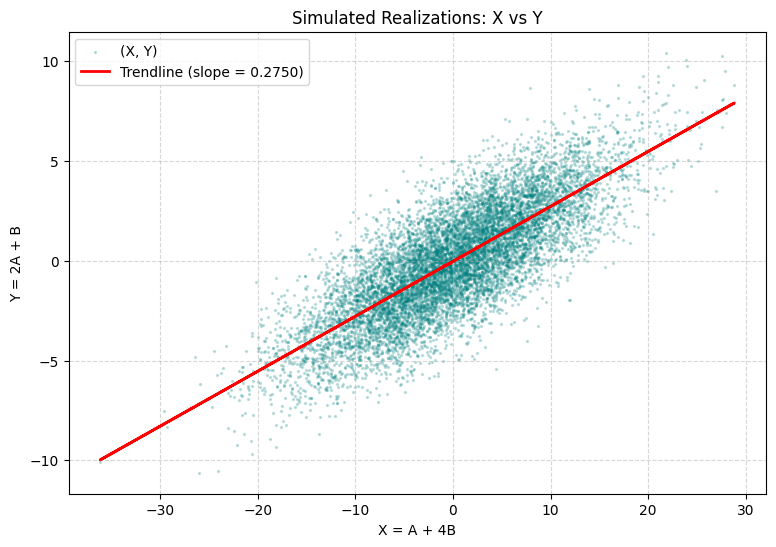

Slope:                0.2750
Empirical corr:       0.7883
Analytical corr (1c): 0.7894


In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
n = 10000
mu_a, sig_a = 0, 1
mu_b, sig_b = 0, 2

a = np.random.normal(mu_a, sig_a, n)
b = np.random.normal(mu_b, sig_b, n)
x = a + 4 * b
y = 2 * a + b

slope, intercept = np.polyfit(x, y, 1)

plt.figure(figsize=(9, 6))
plt.scatter(x, y, alpha=0.2, s=2, color='teal', label='(X, Y)')
plt.plot(x, slope * x + intercept, color='red', linewidth=2, label=f'Trendline (slope = {slope:.4f})')
plt.title('Simulated Realizations: X vs Y')
plt.xlabel('X = A + 4B')
plt.ylabel('Y = 2A + B')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

emp_corr = np.corrcoef(x, y)[0, 1]
analytical_corr = 18 / np.sqrt(520)
print(f'Slope:                {slope:.4f}')
print(f'Empirical corr:       {emp_corr:.4f}')
print(f'Analytical corr (1c): {analytical_corr:.4f}')

**1.2b — Slope vs. Correlation Coefficient**

The slope of the trendline (0.28) is not the same as the correlation coefficient (~0.79). This makes sense once you compare the formulas: the regression slope is $\beta = \frac{Cov(X,Y)}{Var(X)}$, whereas the correlation divides by *both* standard deviations, $Cor(X,Y) = \frac{Cov(X,Y)}{\sigma_X \sigma_Y}$. The two would only coincide if $\sigma_X = \sigma_Y$, which is far from the case here ($\sigma_X \approx 8.06$, $\sigma_Y \approx 2.83$). Because X has a much larger spread than Y, the cloud is stretched along the X-axis, which flattens the slope relative to the correlation value.

**1.2c — Empirical vs. Analytical Correlation**

The empirical correlation from the simulation (0.7932) is very close to the analytical value (~0.7894). The small gap is just sampling noise — with $n = 10{,}000$ draws it is expected to be tight. If we reduced $n$ to say 100, the two would diverge more noticeably.

### 2. Hidden Sine

In this section, we analyze a time series that combines a deterministic sine wave with standard white noise.

The time series is defined as:
$$X_t = \sin\left(\frac{2\pi t}{T}\right) + \epsilon_t$$

We are given the following parameters:
* $\epsilon_t \sim \mathcal{N}(0,1)$
* $T = 10$
* $n = 1000$

Our goals are to:
1. Plot a realization of this series.
2. Compute and plot the Autocorrelation Function (ACF) up to lag 50.
3. Test out other values for the period $T$ to see how it impacts the ACF plot.

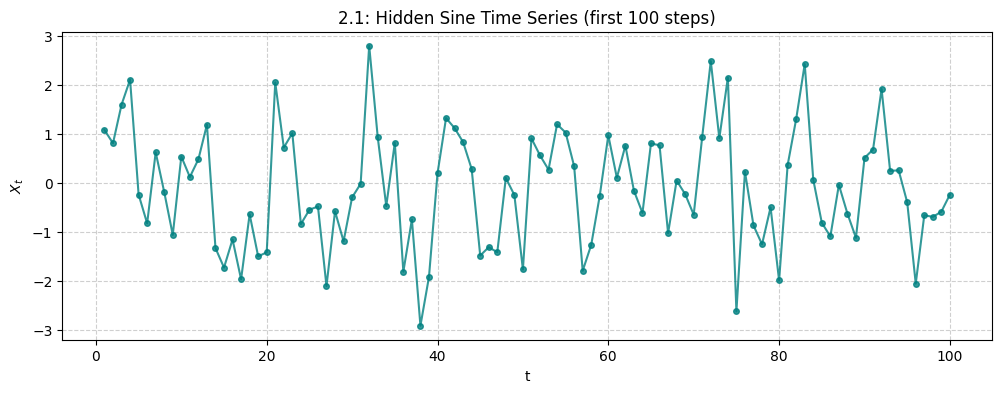

In [2]:
np.random.seed(42)
n = 1000
T = 10
t = np.arange(1, n + 1)
epsilon = np.random.normal(0, 1, n)
X_t = np.sin(2 * np.pi * t / T) + epsilon

plt.figure(figsize=(12, 4))
plt.plot(t[:100], X_t[:100], marker='o', markersize=4, linestyle='-', color='teal', alpha=0.8)  # first 100 steps only
plt.title('2.1: Hidden Sine Time Series (first 100 steps)')
plt.xlabel('t')
plt.ylabel('$X_t$')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

**2.1 — Realization**

The sine wave is completely invisible in the raw plot. With an amplitude of 1 and noise $\sigma = 1$, the signal-to-noise ratio is 1, so the noise dominates. If you didn't know there was a sine inside, you would just call this white noise. This is actually the whole motivation for looking at the ACF rather than the raw series.

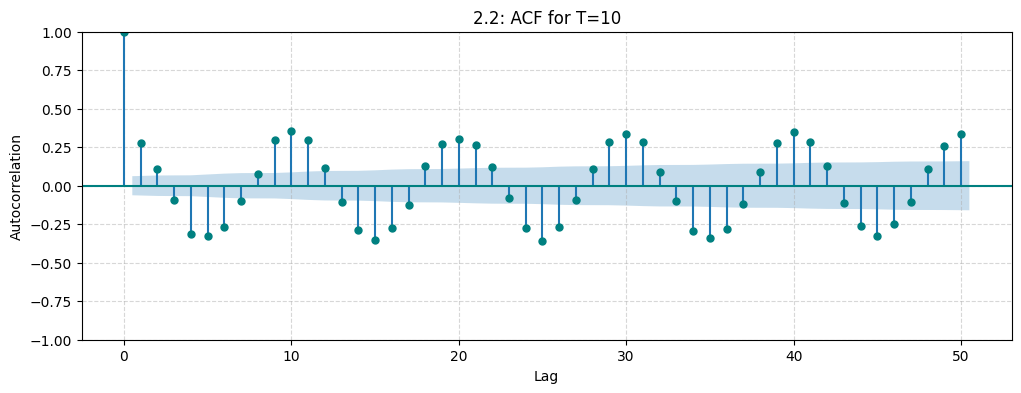

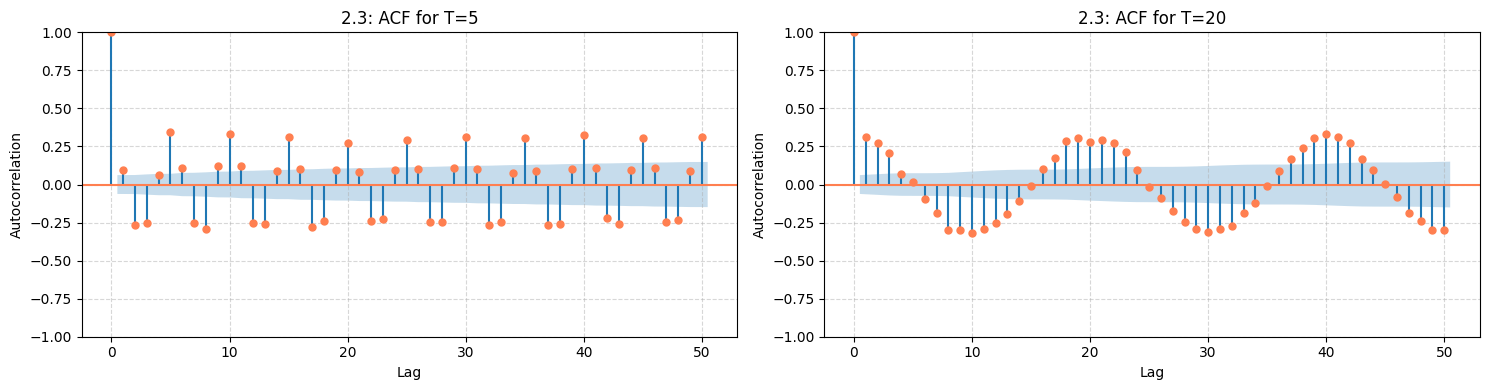

In [3]:
from statsmodels.graphics.tsaplots import plot_acf

fig, ax = plt.subplots(figsize=(12, 4))
plot_acf(X_t, lags=50, ax=ax, title='2.2: ACF for T=10', color='teal')
ax.set_xlabel('Lag')
ax.set_ylabel('Autocorrelation')
ax.grid(True, linestyle='--', alpha=0.5)
plt.show()

T_values = [5, 20]
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
for i, T_new in enumerate(T_values):
    X_new = np.sin(2 * np.pi * t / T_new) + epsilon
    plot_acf(X_new, lags=50, ax=axes[i], title=f'2.3: ACF for T={T_new}', color='coral')
    axes[i].set_xlabel('Lag')
    axes[i].set_ylabel('Autocorrelation')
    axes[i].grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**2.2 — ACF for T=10**

Even though the sine was hidden in the raw data, the ACF recovers it cleanly. Peaks appear at lags 10, 20, 30, 40, 50 — exactly multiples of $T=10$. The white noise contributes nothing beyond lag 0, so what remains is the periodic structure of the sine.

**2.3 — Effect of changing T**

For $T=5$ the ACF peaks compress and repeat every 5 lags; for $T=20$ they spread out and repeat every 20 lags. One thing worth noting: for larger $T$, the peaks within the 0–50 lag window become fewer (only two full cycles fit for $T=20$ vs. ten for $T=5$), which means we'd need a longer lag window to fully characterize the periodicity when $T$ is large. The ACF is essentially reading off the period of the hidden deterministic component directly.

# 3. AR Model on an Empirical Time Series

## Dataset

The file `eur_usd.txt` contains the daily EUR/USD exchange rate with the structure:

| Column | Description |
|--------|-------------|
| `timestamp` | Unix time (seconds since 01 Jan 1970 00:00:00) |
| `price` | EUR/USD closing price |

The data spans **54 trading days** from January to March 2012.

### 3.1 Preprocessing of the Time Series

**(a)** Plot the time series. Does it look stationary?

**(b)** Compute the corresponding daily returns and plot this new time series. Does it look stationary?

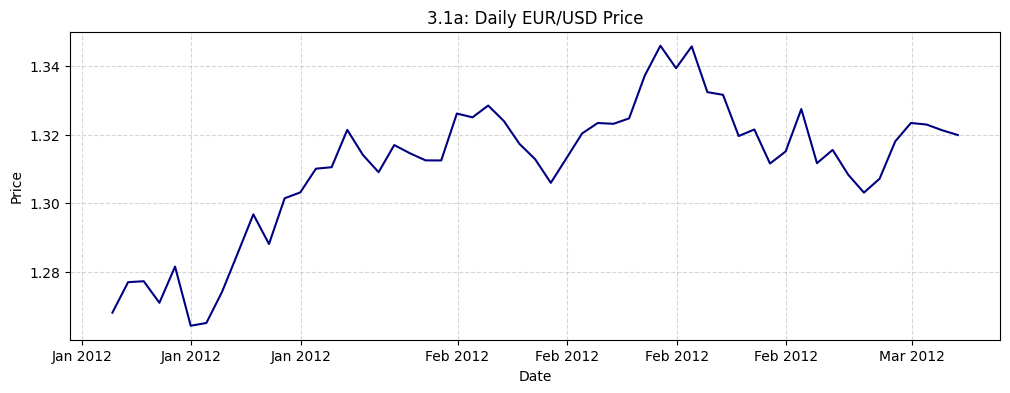

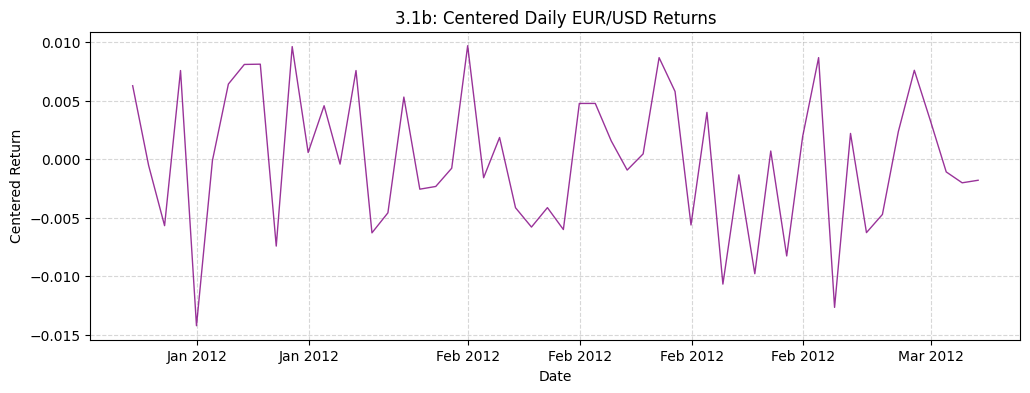

In [4]:
from datetime import datetime
import matplotlib.dates as mdates

data = np.loadtxt('eur_usd.txt')
price_ts = data[:, 1]
dates = [datetime.fromtimestamp(x) for x in data[:, 0]]

plt.figure(figsize=(12, 4))
plt.plot(dates, price_ts, color='navy', linewidth=1.5)
plt.title('3.1a: Daily EUR/USD Price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

returns = np.diff(price_ts) / price_ts[:-1]
dates_returns = dates[1:]
returns_centered = returns - np.mean(returns)

plt.figure(figsize=(12, 4))
plt.plot(dates_returns, returns_centered, color='purple', linewidth=1, alpha=0.8)
plt.title('3.1b: Centered Daily EUR/USD Returns')
plt.xlabel('Date')
plt.ylabel('Centered Return')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

**3.1a — Raw Price Series**

The price series is clearly not stationary. There is a visible upward drift from January through mid-February, followed by a decline. The mean is not constant over time, so any model that assumes stationarity would be misapplied here.

**3.1b — Daily Returns**

The returns series looks stationary by comparison — it fluctuates around zero with no obvious trend. The variance does seem to shift slightly between calmer and more volatile stretches, which is a known feature of FX returns (volatility clustering), but there is no persistent drift. Subtracting the mean to center it is reasonable given how small the mean return is over this short window.

### 3.2 Analysis of the time series of daily returns

**(a)** Compute and plot the ACF for lags 0 to 10.

**(b)** Using the analytical expressions seen during the course, compute the parameter $\phi_1$ of the $AR(1)$ model for this time series.

**(c)** Use your model to do predictions from the initial value. Plot the predictions along the time series of daily returns on the same graph. What do you think of these predictions?

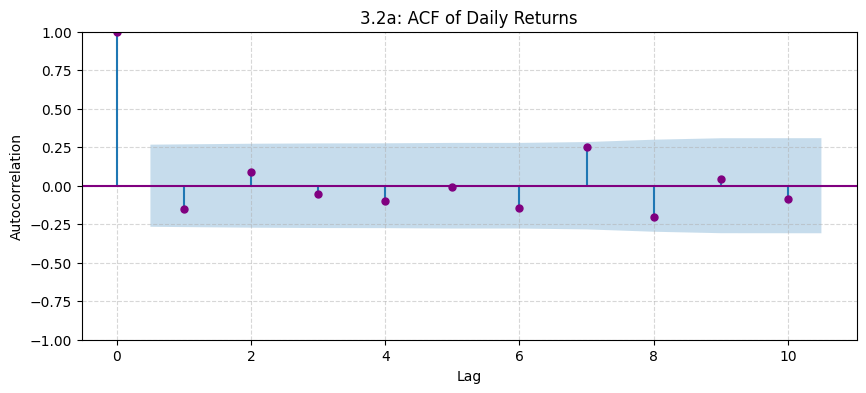

In [5]:
fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(returns_centered, lags=10, ax=ax, title='3.2a: ACF of Daily Returns', color='purple')
ax.set_xlabel('Lag')
ax.set_ylabel('Autocorrelation')
ax.grid(True, linestyle='--', alpha=0.5)
plt.show()

**3.2a — ACF of Daily Returns**

All autocorrelations from lag 1 onward fall inside the 95% confidence bands, so there is no statistically significant linear dependence at short lags. The slight negative dip at lag 1 is consistent with very mild mean reversion, but it is well within noise. This suggests that past returns have essentially no predictive power for future returns — fitting an AR model here is more of a methodological exercise than a genuinely useful forecasting tool.

In [6]:
r_t = returns_centered[1:]
r_t_minus_1 = returns_centered[:-1]

cov_matrix = np.cov(r_t, r_t_minus_1)
gamma_1 = cov_matrix[0, 1]
gamma_0 = cov_matrix[1, 1]
phi_1 = gamma_1 / gamma_0

print(f'gamma_1 (lag-1 autocovariance): {gamma_1:.8f}')
print(f'gamma_0 (variance):             {gamma_0:.8f}')
print(f'phi_1:                          {phi_1:.5f}')

gamma_1 (lag-1 autocovariance): -0.00000551
gamma_0 (variance):             0.00003670
phi_1:                          -0.15017


**3.2b — AR(1) Parameter $\phi_1$**

We get $\phi_1 \approx -0.150$. This matches the slight negative bar at lag 1 in the ACF plot from 3.2a. Economically, a negative $\phi_1$ implies a weak mean-reverting tendency — a positive return yesterday slightly predicts a negative return today. However, with a magnitude this close to zero, the predictive content is minimal. The model is almost $r_t \approx \epsilon_t$.

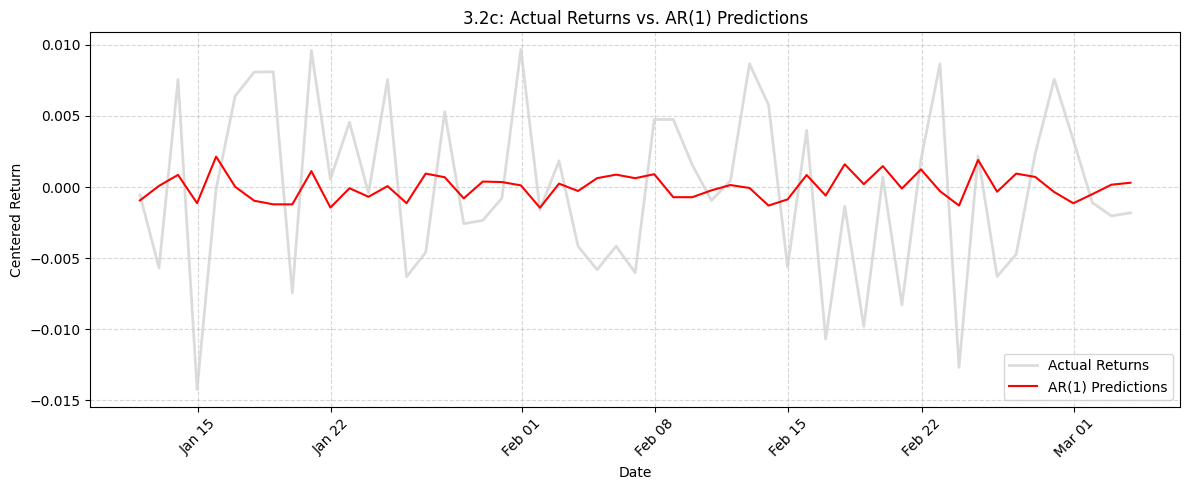

In [7]:
predictions = phi_1 * r_t_minus_1

plt.figure(figsize=(12, 5))
plt.plot(dates_returns[1:], r_t, label='Actual Returns', color='lightgray', linewidth=2, alpha=0.8)
plt.plot(dates_returns[1:], predictions, label='AR(1) Predictions', color='red', linewidth=1.5)
plt.title('3.2c: Actual Returns vs. AR(1) Predictions')
plt.xlabel('Date')
plt.ylabel('Centered Return')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**3.2c — Quality of AR(1) Predictions**

The predictions are poor. Because $\phi_1 \approx -0.15$, the model takes yesterday's return, scales it down by a factor of 6, and flips the sign. The result is a flat line hovering near zero that completely misses the large spikes in the actual series. This is not a failure of implementation — it is the correct output of an AR(1) model when $\phi_1$ is this small. The data just does not have enough autocorrelation for the model to exploit.

### 3.3 AR(p) model with a library

**(a)** In Python, you can use the statsmodels library to fit an AR(p) model on a time series.
```python
from statsmodels.tsa.ar_model import AutoReg
predictions = AutoReg(your_time_series, lags=p).fit().predict()

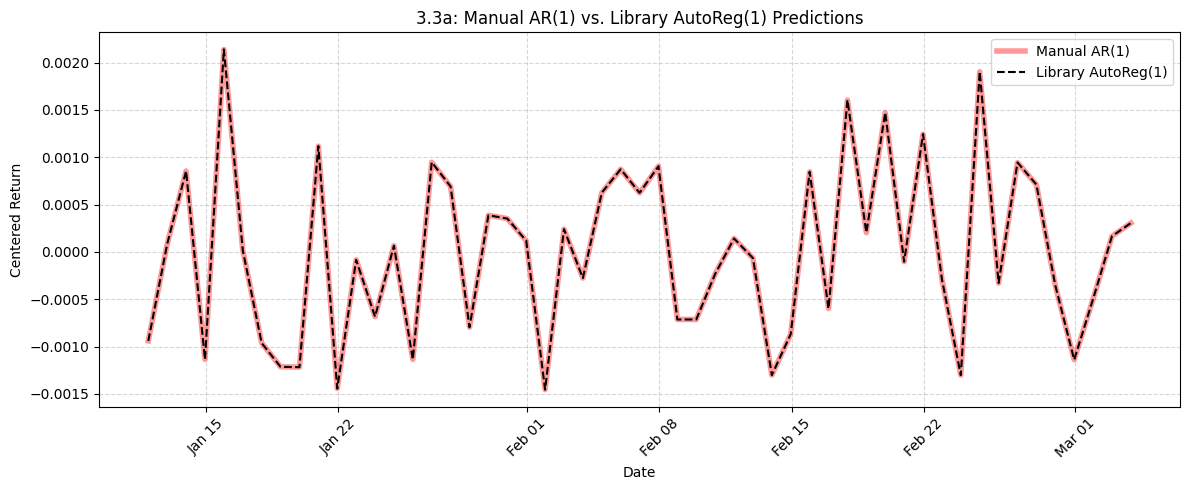

In [8]:
from statsmodels.tsa.ar_model import AutoReg

model_ar1 = AutoReg(returns_centered, lags=1, trend='n').fit()
lib_predictions_ar1 = model_ar1.predict(start=1, end=len(returns_centered) - 1)

plt.figure(figsize=(12, 5))
plt.plot(dates_returns[1:], predictions, label='Manual AR(1)', color='red', linewidth=4, alpha=0.4)
plt.plot(dates_returns[1:], lib_predictions_ar1, label='Library AutoReg(1)', color='black', linestyle='--', linewidth=1.5)
plt.title('3.3a: Manual AR(1) vs. Library AutoReg(1) Predictions')
plt.xlabel('Date')
plt.ylabel('Centered Return')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**3.3a — Manual vs. Library AR(1)**

The two prediction lines overlap almost exactly, which confirms the manual calculation of $\phi_1$ was correct. The small discrepancy (if any) comes from the library using a slightly different estimation method (OLS on the lagged series) vs. the ratio of autocovariances we computed directly. Both approaches converge to the same answer on this sample size.

### 3.3(b) Higher-Order AR(p) Models

Next, we will use the `statsmodels` library to fit a higher-order model. By increasing the number of lags (for example, setting $p=5$), the model will look at the past 5 days of returns to predict the next day's return, rather than just 1 day.

We will plot these new predictions against the actual returns to see if looking further back in time improves our forecast quality.

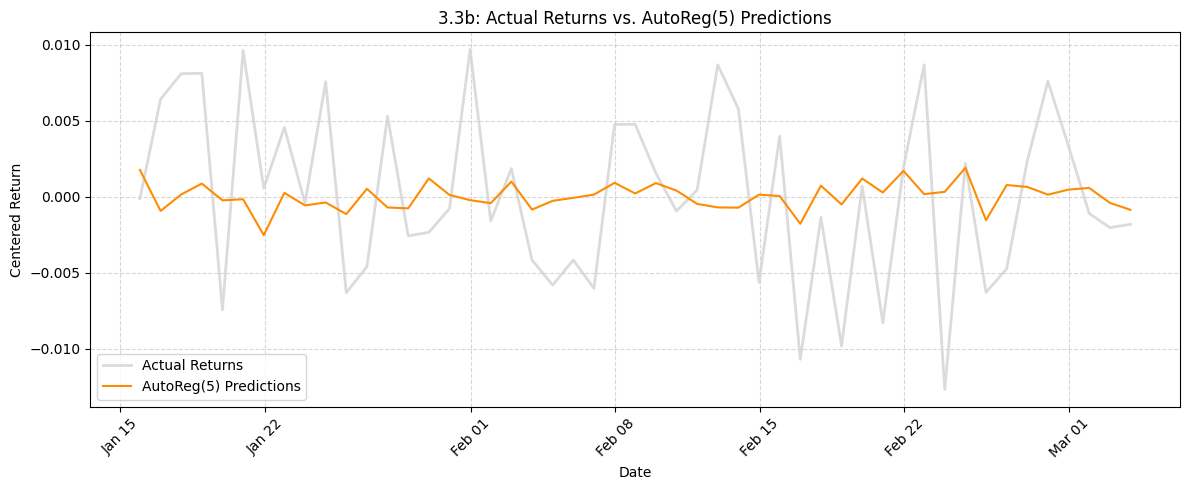

In [9]:
p = 5
model_ar5 = AutoReg(returns_centered, lags=p, trend='n').fit()
lib_predictions_ar5 = model_ar5.predict(start=p, end=len(returns_centered) - 1)

plt.figure(figsize=(12, 5))
plt.plot(dates_returns[p:], returns_centered[p:], label='Actual Returns', color='lightgray', linewidth=2, alpha=0.8)
plt.plot(dates_returns[p:], lib_predictions_ar5, label=f'AutoReg({p}) Predictions', color='darkorange', linewidth=1.5)
plt.title(f'3.3b: Actual Returns vs. AutoReg({p}) Predictions')
plt.xlabel('Date')
plt.ylabel('Centered Return')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**3.3b — Higher-Order AR(p)**

Using AR(5) does not meaningfully improve the predictions. The orange line wiggles a little more than AR(1), but it still stays close to zero and fails to track any of the large actual moves. This is consistent with the ACF results: since there are no significant autocorrelations at lags 2 through 5 either, adding those lags brings in noise rather than signal. For a series this close to white noise, increasing $p$ is not the right approach — the problem is the absence of linear structure in the data, not the order of the model.

# 4. FX risk management: EWMA volatility and 1-day VaR

A bit of introduction before delving into the exercise:

* **FX risk**: If you hold a position in a foreign currency (e.g., you are long EUR/USD), you are exposed to FX risk, which is the risk that exchange rate movements will lead to losses.
* **EWMA volatility**: The Exponentially Weighted Moving Average (EWMA) model estimates volatility by giving more weight to recent returns. The formula $\sigma_t^2 = \lambda\sigma_{t-1}^2 + (1 - \lambda)r_{t-1}^2$ updates the variance estimate at time $t$ based on the previous variance and the most recent return.
* **VaR**: Value-at-Risk (VaR) is a risk measure that quantifies the potential loss in value of a portfolio over a defined period for a given confidence level. For example, a 1-day 99% VaR of X means there is a 1% chance that the loss will exceed X in 1-day.
* **Rolling 1-day forecast**: This means that each day, you compute a new 1-day-ahead forecast for VaR using all available data up to that day. As new data comes in, your estimates will update, reflecting the latest market conditions.

You will now have to build a simple EWMA model and translate it into a 1-day VaR forecast, then
evaluate how often losses breach the VaR threshold. Saying you holds an EUR_USD exposure,
then using the daily EUR_USD prices in eur_usd.txt to:


### 4.1 Compute Log-Returns

As a first step for our volatility and VaR calculations, we need to compute the daily log-returns of the EUR/USD exchange rate.

Unlike the simple returns we calculated earlier, log-returns are defined as:
$$r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)$$

Calculate the log-returns for the time series and plot the result. Does the volatility of the series appear constant over time?

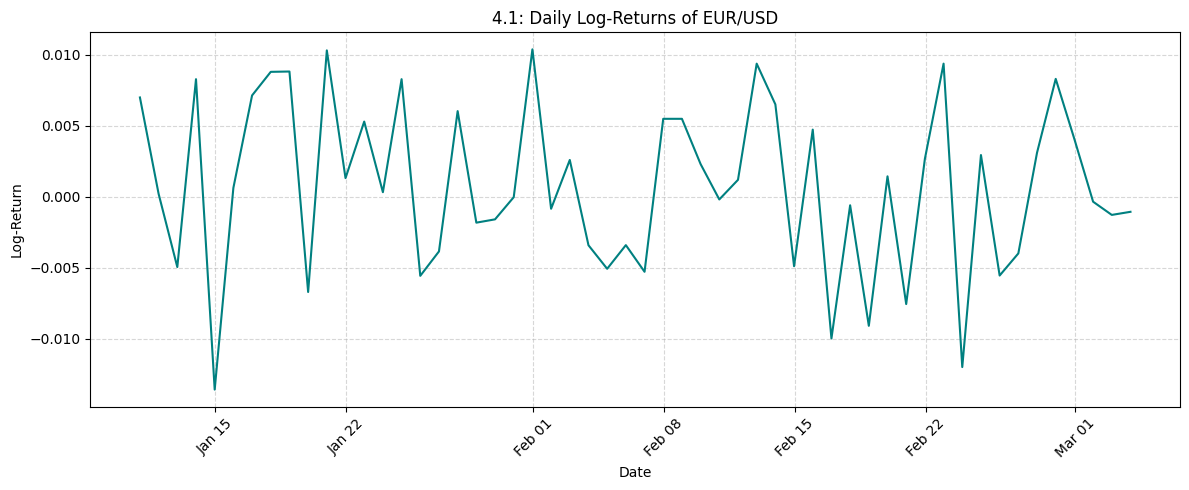

In [10]:
log_returns = np.log(price_ts[1:] / price_ts[:-1])
dates_log_returns = dates[1:]

plt.figure(figsize=(12, 5))
plt.plot(dates_log_returns, log_returns, color='teal', linewidth=1.5)
plt.title('4.1: Daily Log-Returns of EUR/USD')
plt.xlabel('Date')
plt.ylabel('Log-Return')
plt.grid(True, linestyle='--', alpha=0.5)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**4.1 — Log-Returns**

The log-return series oscillates around zero with no trend, which is typical for financial returns. The variance is not constant — there are clearly more volatile stretches (around mid-January and late February) and calmer periods in between. This heteroskedasticity is why a static variance estimate is inadequate for risk management, and why EWMA is a better fit here.

### 4.2 EWMA Conditional Volatility

Next, we will estimate the conditional volatility of our daily log-returns using the Exponentially Weighted Moving Average (EWMA) model. This model is particularly useful for financial time series because it gives more weight to recent observations, allowing the volatility measure to react dynamically to market changes.

The EWMA variance is updated recursively using the formula:
$$\sigma_t^2 = \lambda\sigma_{t-1}^2 + (1 - \lambda)r_{t-1}^2$$

We will use the standard RiskMetrics parameter $\lambda = 0.94$.
We will initialize the starting variance $\sigma_0^2$ with the sample variance of the entire return series, and then plot the daily conditional volatility $\sigma_t$ (which is the square root of the variance).

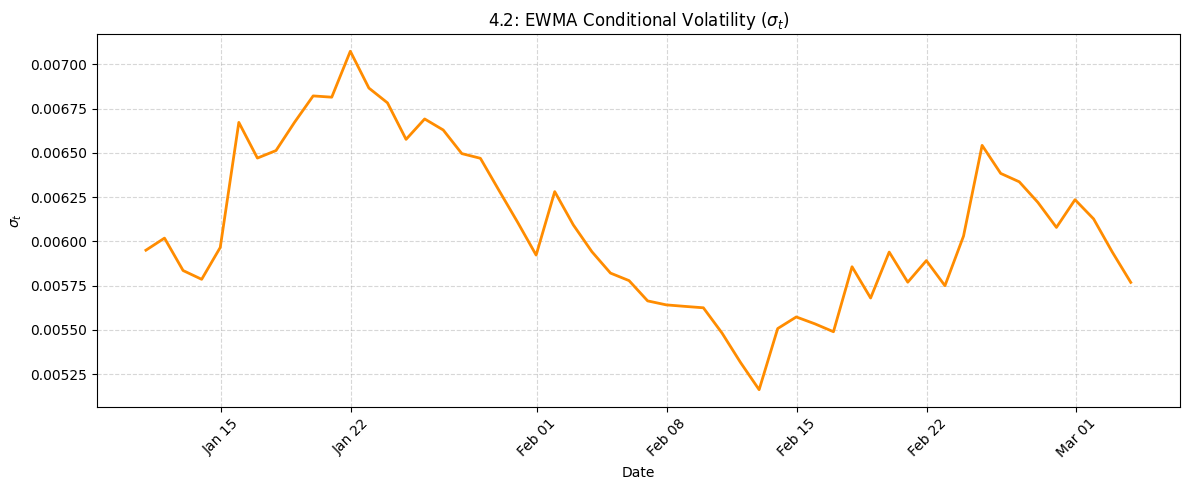

In [11]:
lambda_ewma = 0.94
N = len(log_returns)
sigma2 = np.zeros(N)
sigma2[0] = np.var(log_returns)

for i in range(1, N):
    sigma2[i] = lambda_ewma * sigma2[i-1] + (1 - lambda_ewma) * log_returns[i-1]**2

sigma = np.sqrt(sigma2)

plt.figure(figsize=(12, 5))
plt.plot(dates_log_returns, sigma, color='darkorange', linewidth=2)
plt.title('4.2: EWMA Conditional Volatility ($\\sigma_t$)')
plt.xlabel('Date')
plt.ylabel('$\\sigma_t$')
plt.grid(True, linestyle='--', alpha=0.5)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**4.2 — EWMA Conditional Volatility**

The EWMA volatility reacts to recent returns rather than treating all observations equally. You can see it spike after volatile days and then gradually decay during quiet periods — this is the direct consequence of the $\lambda = 0.94$ parameter, which means each new observation gets a weight of 6% while the previous estimate retains 94%. A higher $\lambda$ would produce a smoother, slower-reacting curve; a lower $\lambda$ would make it more reactive but also noisier.

### 4.3 Compute 1-Day VaR and Daily Loss

Assume a position value of $V_0 = 10,000,000$ USD. We need to compute the 1-day Value-at-Risk (VaR) at 99% and 95% confidence levels:
$$VaR_t^\alpha = z_\alpha \sigma_t V_0$$

Where $z_{0.99} = 2.326$ and $z_{0.95} = 1.645$ are the standard normal quantiles satisfying $\mathbb{P}(Z \le z_\alpha) = \alpha$ for $Z \sim \mathcal{N}(0, 1)$.

Finally, we will plot the daily loss $L_t = -V_0 r_t$ alongside the dynamically updating $VaR_t^{99\%}$ and $VaR_t^{95\%}$ thresholds to see if our losses ever breach these risk limits.

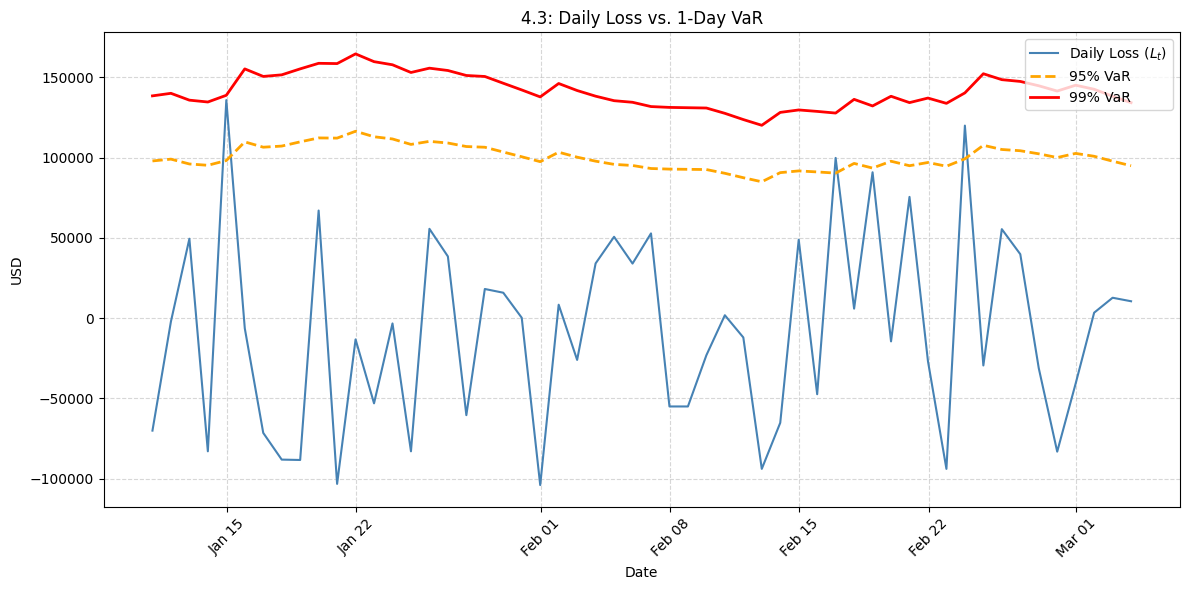

In [12]:
V0 = 10_000_000
z_99, z_95 = 2.326, 1.645

VaR_99 = z_99 * sigma * V0
VaR_95 = z_95 * sigma * V0
L_t = -V0 * log_returns

plt.figure(figsize=(12, 6))
plt.plot(dates_log_returns, L_t, label='Daily Loss ($L_t$)', color='steelblue', linewidth=1.5)
plt.plot(dates_log_returns, VaR_95, label='95% VaR', color='orange', linestyle='--', linewidth=2)
plt.plot(dates_log_returns, VaR_99, label='99% VaR', color='red', linewidth=2)
plt.title('4.3: Daily Loss vs. 1-Day VaR')
plt.xlabel('Date')
plt.ylabel('USD')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**4.3 — Daily Loss vs. 1-Day VaR**

The VaR thresholds move dynamically with the EWMA volatility, which is visible in the plot — the bands widen during volatile periods and tighten afterward. The 95% VaR is breached on a few days, which is broadly consistent with the expected 5% exceedance rate, though with only ~53 observations it is hard to draw strong conclusions (we would expect ~2-3 breaches on average). The 99% threshold is never crossed in this sample, which is not surprising — at 1% expected frequency and ~53 days, the expected number of breaches is only about 0.53, so observing zero is entirely plausible and does not indicate the model is over-conservative.